In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

In [2]:
# 1. Activate the Dark Mode Base
plt.style.use("dark_background")

# 2. The "Cyberpunk" Custom Overrides
plt.rcParams.update({
    "figure.facecolor": "#0d0d0d",      # Pitch black (almost) background
    "axes.facecolor": "#0d0d0d",        # Match the figure
    "axes.edgecolor": "#00ffff",        # Cyan borders
    "axes.linewidth": 1.5,              # Thicker borders
    "grid.color": "#2a2a2a",            # Subtle grey grid
    "grid.linewidth": 0.5,
    "text.color": "#ffffff",            # White text
    "axes.labelcolor": "#00ff9d",       # Matrix Green labels
    "xtick.color": "#00ff9d",           # Matrix Green ticks
    "ytick.color": "#00ff9d",
    "font.family": "monospace",         # The "Hacker" font
    "figure.dpi": 120                   # Higher resolution for the glow
})

# 3. The Neon Color Palette (Cyan vs. Hot Pink)
# We will use this 'neon_palette' variable in all your charts instead of 'Set2'
neon_palette = ["#00FFFF", "#FF00FF"]   # Cyan for Metallica, Magenta for Sepultura

neon_colors = [
    "#FF00FF", # Neon Magenta
    "#00FFFF", # Electric Cyan
    "#00FF00", # Neon Green
    "#FFFF00", # Neon Yellow
    "#FF0000", # Neon Red
    "#FF6EC7", # Neon Pink
    "#BFFF00", # Lime Green
    "#FF9933", # Neon Orange
    "#9D00FF", # Neon Purple
    "#0000FF", # Electric Blue
    "#CCFF00", # Electric Lime
    "#FF355E", # Radical Red
    "#80FF00", # Bright Chartreuse
    "#AAF0D1", # Magic Mint
    "#FF007F", # Bright Rose
    "#00FFEF", # Turquoise Surf
    "#FFF01F", # 24K Gold Neon
    "#FF4422", # Flamethrower Orange
    "#39FF14", # Alien Green
    "#BCFF00"  # Neon Sulfur
]

In [3]:
# Reading from the CSV file
df = pd.read_csv("/kaggle/input/datasets/priyangshumukherjee/mental-health-text-classification-dataset/mental_heath_unbanlanced.csv")

display(df['status'].unique())

display(df.info())

array(['Anxiety', 'Normal', 'Depression', 'Suicidal'], dtype=object)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49612 entries, 0 to 49611
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Unique_ID  40012 non-null  float64
 1   text       49612 non-null  object 
 2   status     49612 non-null  object 
dtypes: float64(1), object(2)
memory usage: 1.1+ MB


None

In [4]:
# Cleaning the dataset
df_clean = df.drop(columns=['Unique_ID'])
df_clean['cleaned_text'] = df_clean['text'].str.lower().str.replace(r'[^a-z\s]', '', regex=True)
pd.set_option('display.width', 1000)
print(df_clean[['text', 'cleaned_text', 'status']].head())

                                                text                                       cleaned_text   status
0                                         oh my gosh                                         oh my gosh  Anxiety
1  trouble sleeping, confused mind, restless hear...  trouble sleeping confused mind restless heart ...  Anxiety
2  All wrong, back off dear, forward doubt. Stay ...  all wrong back off dear forward doubt stay in ...  Anxiety
3  I've shifted my focus to something else but I'...  ive shifted my focus to something else but im ...  Anxiety
4  I'm restless and restless, it's been a month n...  im restless and restless its been a month now ...  Anxiety


In [5]:
# Average word count per status
df_clean['word_count'] = df_clean['cleaned_text'].apply(lambda x: len(str(x).split()))

avg_words_status = df_clean.groupby('status')['word_count'].mean().round(2).reset_index()

print(avg_words_status.head())

       status  word_count
0     Anxiety      122.29
1  Depression      105.48
2      Normal       23.09
3    Suicidal      109.04


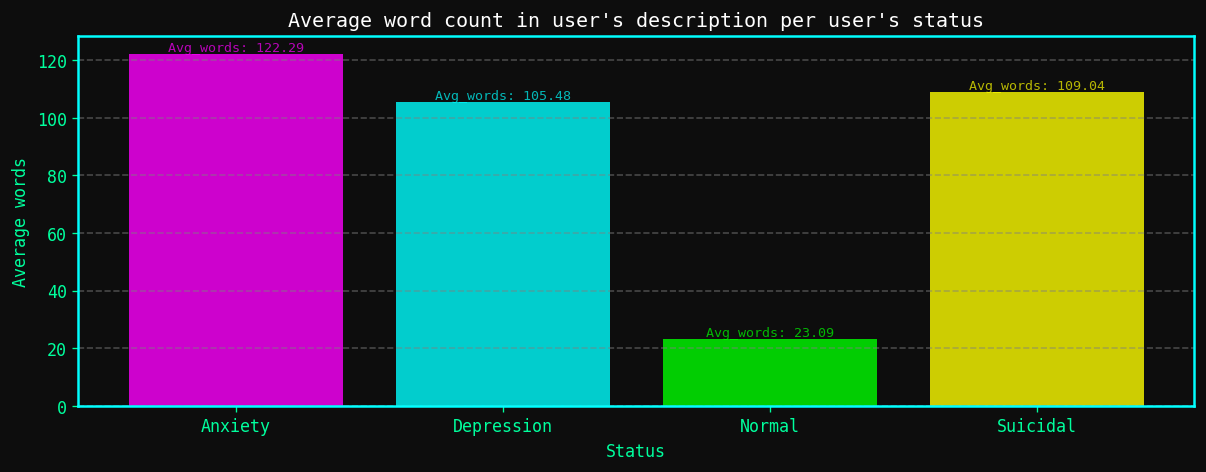

In [6]:
plt.figure(figsize=(12, 4))
plt.bar(avg_words_status['status'],
        avg_words_status['word_count'],
        color=neon_colors,
        alpha=0.8)

for i in range(len(avg_words_status)):
    plt.text(avg_words_status['status'].iloc[i],
             avg_words_status['word_count'].iloc[i],
             f"Avg_words: {avg_words_status['word_count'].iloc[i]}",
             color=neon_colors[i],
             fontsize=8,
             ha='center',
             va='bottom',
             alpha=0.7)

plt.ylabel('Average words')
plt.xlabel('Status')
plt.title('Average word count in user\'s description per user\'s status')
plt.grid(axis='y', alpha=0.5, color='grey', linestyle='--', lw=1)
plt.show()

In [7]:
# Initialize the engine (setting a limit so we don't blow the server)
vectorizer = TfidfVectorizer(max_features=5000)

# Fit and transform the text into a mathematical matrix (X)
X = vectorizer.fit_transform(df_clean['cleaned_text'])

# Define the target variables (y)
y = df_clean['status']

# Check the shape of the new mathematical grid
print(X.shape)


(49612, 5000)


In [8]:
# Split the data into 4 new variables (Train features, Test features, Train answers, Test answers)
# test_size=0.2 means we hide 20% of the data for testing. 
# random_state=42 is just a seed number that ensures the random shuffle happens the exact same way every time you run the code.
# X represents 80% of the training portion of the entire 'pool', y represents 20% of the entire pool a test (final exam)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
# Initialize the engine with our custom tactical parameters
# We increase max_iter (maximum iterations) just to give the math enough time to converge
classifier = LogisticRegression(class_weight='balanced', max_iter=1000)

# Train the model using ONLY the training data
# This is where the actual 'learning' happens. It might take a few seconds to process!
# X_train - 80% of the questions, y_train - 80% of the answer keys for those questions.
classifier.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [10]:
# Unleash the model to make its guesses on the hidden test data
# X_test - the 20% hidden data for the machine learning to solve (like an exam you were studying for using the available 80% (X_train) of the conent)
y_pred = classifier.predict(X_test)
# y_test - answer key for the 20% exam
table_dict = classification_report(y_test, y_pred, output_dict=True)

df_table = pd.DataFrame(data=table_dict)
df_table_pivot = pd.pivot_table(data=df_table, columns=['precision', 'recall', 'f1-score', 'support'])

print(df_table_pivot)

              f1-score  precision    recall      support
Anxiety       0.798680   0.742331  0.864286  1120.000000
Depression    0.695330   0.757368  0.642686  2919.000000
Normal        0.913809   0.900371  0.927655  3663.000000
Suicidal      0.682502   0.661318  0.705088  2221.000000
accuracy      0.786859   0.786859  0.786859     0.786859
macro avg     0.772580   0.765347  0.784929  9923.000000
weighted avg  0.784774   0.786961  0.786859  9923.000000


In [12]:
# Generate the dictionary
report_dict = classification_report(y_test, y_pred, output_dict=True)

# Convert to DataFrame, drop the unwanted columns and instantly trnspose (pivot) with .T, reset the index and rename it to 'status'
df_clean_report = pd.DataFrame(report_dict).drop(['accuracy', 'macro avg', 'weighted avg'], axis=1).T.reset_index().rename(columns={'index': 'status'})

# Convert metrics to percentile
df_clean_report[['precision', 'recall', 'f1-score']] = round(df_clean_report[['precision', 'recall', 'f1-score']] * 100, 2)

print(df_clean_report)

       status  precision  recall  f1-score  support
0     Anxiety      74.23   86.43     79.87   1120.0
1  Depression      75.74   64.27     69.53   2919.0
2      Normal      90.04   92.77     91.38   3663.0
3    Suicidal      66.13   70.51     68.25   2221.0


<Figure size 1440x480 with 0 Axes>

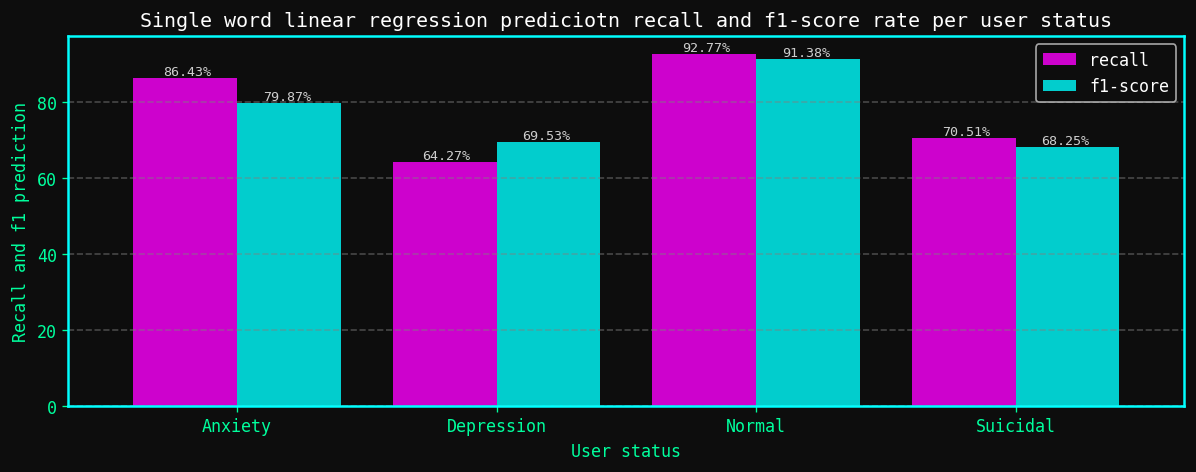

In [13]:
plt.figure(figsize=(12, 4))

ax = df_clean_report.plot(x='status',
         y=['recall', 'f1-score'],
         kind='bar',
         rot=0,
         color=neon_colors,
         alpha=0.8,
         width=0.8,
         figsize=(12, 4))

x_text = np.arange(len(df_clean_report['status']))

for i in range(len(df_clean_report)):
    plt.text(x_text[i]-0.1,
            df_clean_report['recall'].iloc[i],
            f"{df_clean_report['recall'].iloc[i]}%",
            alpha=0.8,
            fontsize=8,
            ha='right',
            va='bottom')

for i in range(len(df_clean_report)):
    plt.text(x_text[i]+0.1,
            df_clean_report['f1-score'].iloc[i],
            f"{df_clean_report['f1-score'].iloc[i]}%",
            alpha=0.8,
            fontsize=8,
            ha='left',
            va='bottom')

plt.title('Single word linear regression prediciotn recall and f1-score rate per user status')
plt.ylabel('Recall and f1 prediction')
plt.xlabel('User status')
plt.grid(axis='y', color='grey', alpha=0.5, lw=1, linestyle='--')
plt.show()

In [14]:
# Initialize the upgradwd engine (looking at 1-word AND 2-word phrases)
vectorizer_advanced = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))

# Transform the text into the new bigrams
X_advanced = vectorizer_advanced.fit_transform(df_clean['cleaned_text'])

# Split the new data
X_train_adv, X_test_adv, y_train, y_test = train_test_split(X_advanced, y, test_size=0.2, random_state=42)

# Train the model on the new data
classifier.fit(X_train_adv, y_train)

# New predictions
y_pred_adv = classifier.predict(X_test_adv)

report_dict = classification_report(y_test, y_pred_adv, output_dict=True)

In [15]:
# Bigram dataset
df_adv_report = pd.DataFrame(report_dict)
print(df_adv_report)

               Anxiety   Depression       Normal     Suicidal  accuracy    macro avg  weighted avg
precision     0.747109     0.756713     0.897814     0.666667   0.78827     0.767076      0.787561
recall        0.865179     0.646797     0.930658     0.700585   0.78827     0.785805      0.788270
f1-score      0.801820     0.697451     0.913941     0.683205   0.78827     0.774104      0.785958
support    1120.000000  2919.000000  3663.000000  2221.000000   0.78827  9923.000000   9923.000000


In [16]:
# Cleaning the dataset for the Bigram
clean_report = df_adv_report.drop(['accuracy', 'macro avg', 'weighted avg'], axis=1).T.reset_index().rename(columns={'index':'status'})

print(clean_report)

       status  precision    recall  f1-score  support
0     Anxiety   0.747109  0.865179  0.801820   1120.0
1  Depression   0.756713  0.646797  0.697451   2919.0
2      Normal   0.897814  0.930658  0.913941   3663.0
3    Suicidal   0.666667  0.700585  0.683205   2221.0


<Figure size 1440x480 with 0 Axes>

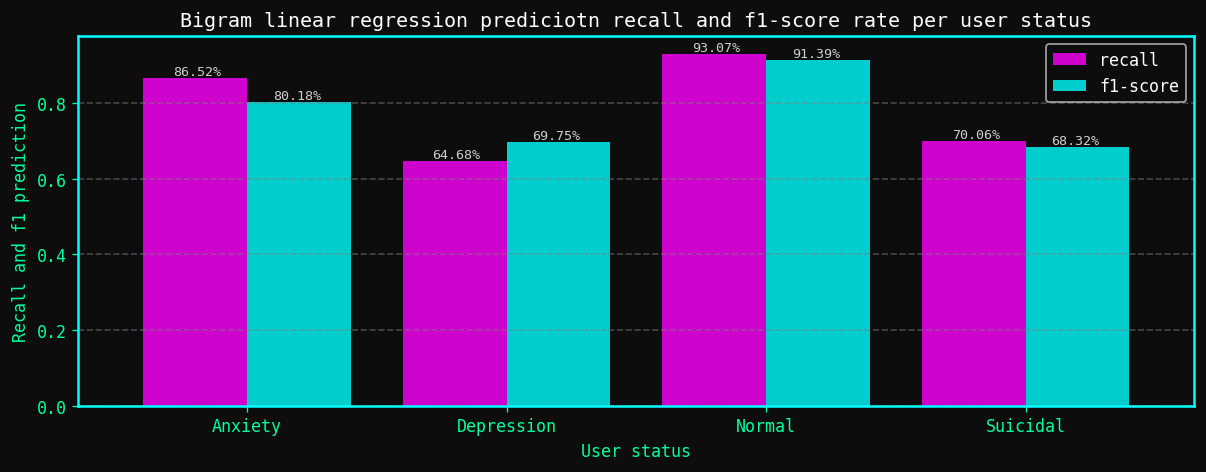

In [17]:
plt.figure(figsize=(12, 4))

ax = clean_report.plot(x='status',
         y=['recall', 'f1-score'],
         kind='bar',
         rot=0,
         color=neon_colors,
         alpha=0.8,
         width=0.8,
         figsize=(12, 4))

x_text = np.arange(len(clean_report['status']))

for i in range(len(clean_report)):
    plt.text(x_text[i]-0.1,
            clean_report['recall'].iloc[i],
            f"{clean_report['recall'].iloc[i]*100:.2f}%",
            alpha=0.8,
            fontsize=8,
            ha='right',
            va='bottom')

for i in range(len(clean_report)):
    plt.text(x_text[i]+0.1,
            clean_report['f1-score'].iloc[i],
            f"{clean_report['f1-score'].iloc[i]*100:.2f}%",
            alpha=0.8,
            fontsize=8,
            ha='left',
            va='bottom')

plt.title('Bigram linear regression prediciotn recall and f1-score rate per user status')
plt.ylabel('Recall and f1 prediction')
plt.xlabel('User status')
plt.grid(axis='y', color='grey', alpha=0.5, lw=1, linestyle='--')
plt.show()